In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("ML-EdgeIIoT-dataset.csv", low_memory=False)

In [3]:
#encode data labels of attack types
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Attack_type'] = label_encoder.fit_transform(df['Attack_type'])
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(label_mapping)

{'Backdoor': np.int64(0), 'DDoS_HTTP': np.int64(1), 'DDoS_ICMP': np.int64(2), 'DDoS_TCP': np.int64(3), 'DDoS_UDP': np.int64(4), 'Fingerprinting': np.int64(5), 'MITM': np.int64(6), 'Normal': np.int64(7), 'Password': np.int64(8), 'Port_Scanning': np.int64(9), 'Ransomware': np.int64(10), 'SQL_injection': np.int64(11), 'Uploading': np.int64(12), 'Vulnerability_scanner': np.int64(13), 'XSS': np.int64(14)}


In [4]:
non_numeric_cols = df.select_dtypes(include=['object']).columns
print(non_numeric_cols)

Index(['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4',
       'arp.src.proto_ipv4', 'http.file_data', 'http.request.uri.query',
       'http.request.method', 'http.referer', 'http.request.full_uri',
       'http.request.version', 'tcp.options', 'tcp.payload', 'tcp.srcport',
       'dns.qry.name.len', 'mqtt.conack.flags', 'mqtt.msg', 'mqtt.protoname',
       'mqtt.topic'],
      dtype='object')


In [5]:
df.drop(columns=non_numeric_cols, inplace=True, errors='ignore')

In [6]:
df = df.drop(["icmp.unused","http.tls_port","mqtt.msg_decoded_as"], axis =1)

In [7]:
X = df.drop(['Attack_label','Attack_type'], axis=1)
y = df['Attack_type']

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
from collections import Counter

counter = Counter(y_train)
majority = max(counter.values())
class_weights = {cls: majority/count for cls, count in counter.items()}

sample_weights = y_train.map(class_weights)


In [10]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    objective='multi:softprob',   # for multi-class
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train, sample_weight=sample_weights)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [11]:
y_pred = xgb.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9213244613434728

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.97      2039
           1       0.74      0.91      0.82      2112
           2       1.00      1.00      1.00      2818
           3       1.00      1.00      1.00      2050
           4       1.00      1.00      1.00      2900
           5       0.51      0.79      0.62       200
           6       0.40      1.00      0.57       243
           7       0.98      0.98      0.98      4860
           8       0.84      0.77      0.80      1998
           9       0.96      0.93      0.94      2014
          10       0.96      0.87      0.91      2185
          11       0.83      0.84      0.83      2062
          12       0.93      0.85      0.89      2054
          13       0.99      0.96      0.97      2015
          14       0.88      0.78      0.83      2010

    accuracy                           0.92     31560
   macro avg       0.87   

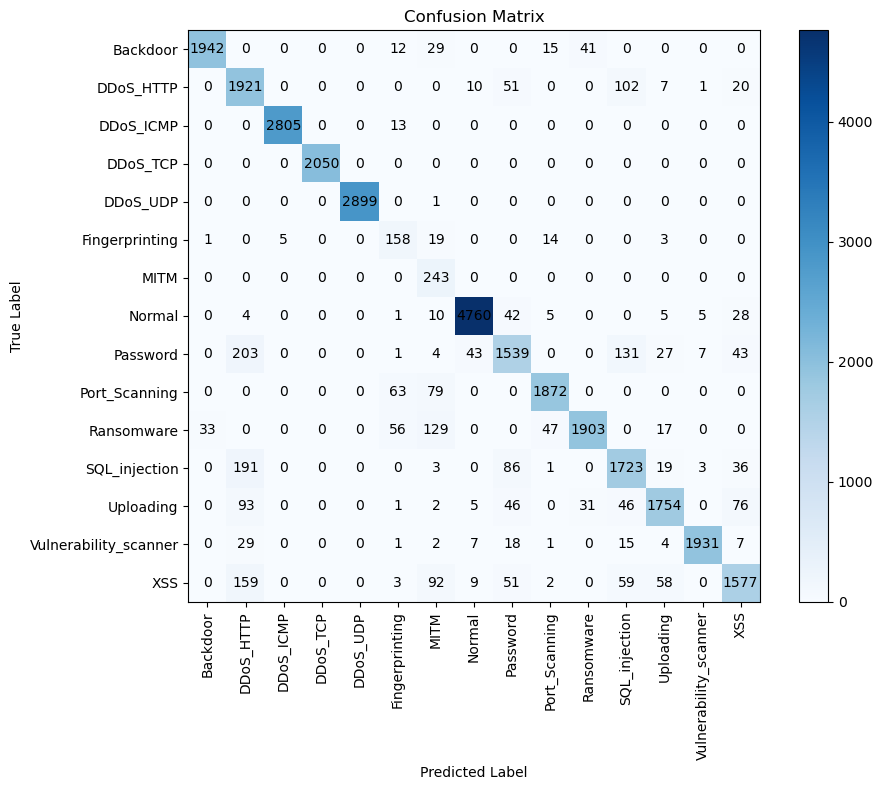

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
plt.imshow(
    cm,
    interpolation='nearest',
    cmap=plt.cm.Blues,   # Blue color map
    vmin=0,              # Force 0 to be white
    vmax=cm.max()        # Max value = darkest blue
)

plt.title("Confusion Matrix")
plt.colorbar()

class_names = label_encoder.classes_
tick_marks = np.arange(len(class_names))

plt.xticks(tick_marks, class_names, rotation=90)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
        
plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb, X, y, cv=5, scoring='accuracy')
print("Mean CV accuracy:", scores.mean())
print("Std:", scores.std())

Mean CV accuracy: 0.8922813688212926
Std: 0.02140208978880057


In [14]:
from sklearn.preprocessing import label_binarize

if len(y_test.shape) == 1:
    y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
else:
    y_test_bin = y_test

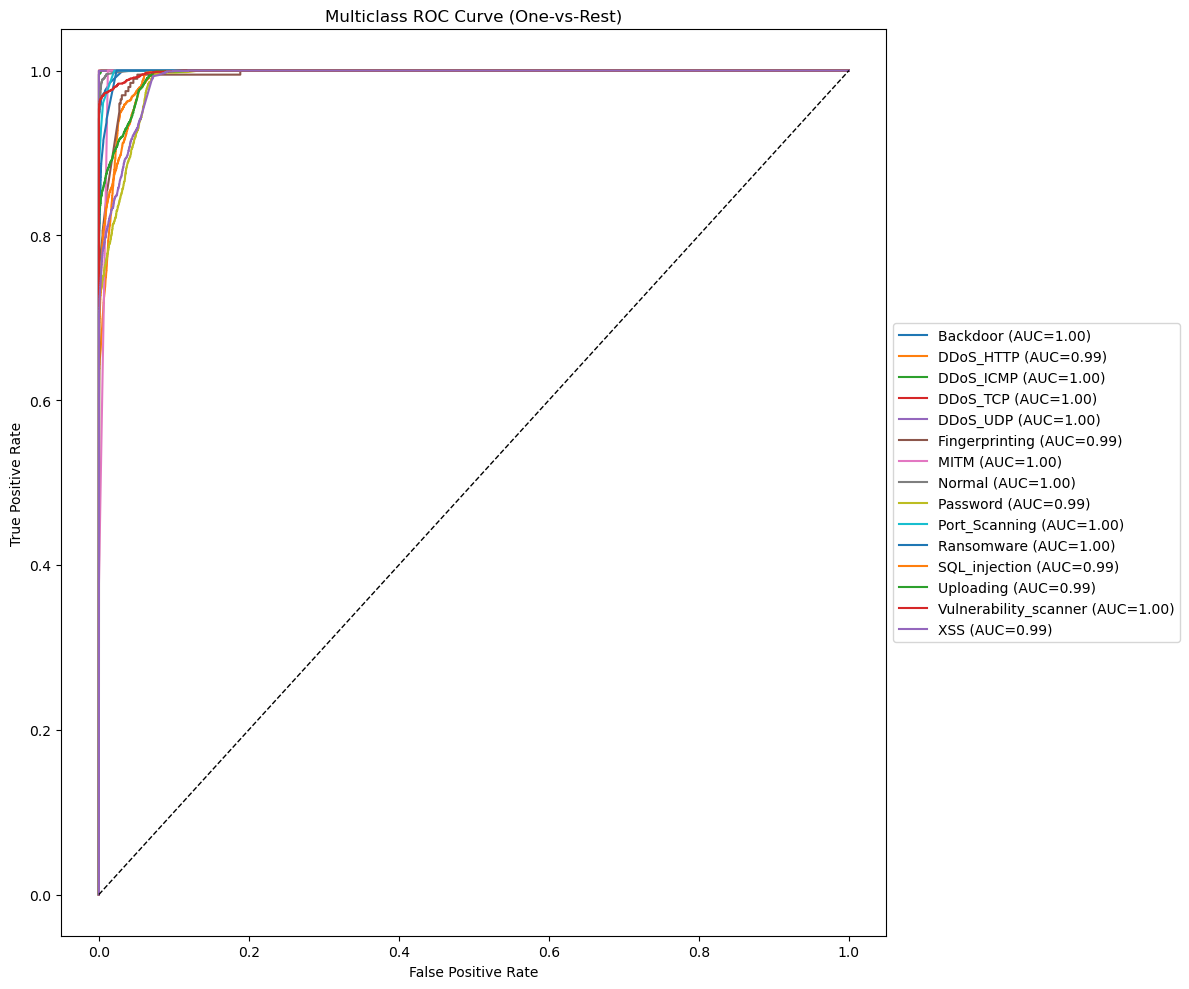

In [15]:
y_score = xgb.predict_proba(X_test)
from sklearn.metrics import roc_curve, auc
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(12,10))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=1.5,
             label=f'{class_names[i]} (AUC={roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--', lw=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (One-vs-Rest)")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))  # legend outside
plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import roc_auc_score

macro_auc = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')
print("Macro AUC:", macro_auc)

Macro AUC: 0.9967174964168198


In [17]:
# Get class names
class_names = label_encoder.classes_

# Compute AUC per class
auc_scores = []

for i in range(len(class_names)):
    auc = roc_auc_score(y_test_bin[:, i], y_score[:, i])
    auc_scores.append(auc)

# Create table
auc_table = pd.DataFrame({
    "Class": class_names,
    "AUC": auc_scores
})

print(auc_table)

                    Class       AUC
0                Backdoor  0.999455
1               DDoS_HTTP  0.993231
2               DDoS_ICMP  0.999991
3                DDoS_TCP  1.000000
4                DDoS_UDP  0.999997
5          Fingerprinting  0.994936
6                    MITM  0.996305
7                  Normal  0.999722
8                Password  0.990525
9           Port_Scanning  0.999261
10             Ransomware  0.998506
11          SQL_injection  0.993530
12              Uploading  0.994842
13  Vulnerability_scanner  0.998895
14                    XSS  0.991566
